<a href="https://colab.research.google.com/github/bouzianyounes85-dotcom/BUB1B-SAR-ML/blob/main/Copy_of_Bub1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# No installation needed — use pandas to read directly
import pandas as pd

# Search BindingDB via their direct URL for BUB1B
url = "https://www.bindingdb.org/axis2/services/BDBService/getLigandsByTarget?targetname=BUB1B&response=application/json"

# Alternative: use a well-studied similar kinase
# BUB1 (brother kinase) has much more data in ChEMBL
results = activity.filter(
    target_chembl_id="CHEMBL3778",  # BUB1 kinase
    standard_type="IC50"
).only(['molecule_chembl_id',
        'canonical_smiles',
        'standard_value'])

data = list(results)
print(f"Found {len(data)} compounds")

Found 11068 compounds


In [ ]:
import pandas as pd
import numpy as np

# Convert to dataframe
df_chembl = pd.DataFrame(data)
print(f"Raw data: {len(df_chembl)} compounds")

# Remove missing values
df_chembl = df_chembl.dropna(subset=['canonical_smiles', 'standard_value'])

# Convert IC50 to numeric
df_chembl['IC50_nM'] = pd.to_numeric(df_chembl['standard_value'], errors='coerce')

# Remove impossible values
df_chembl = df_chembl[df_chembl['IC50_nM'] > 0]
df_chembl = df_chembl[df_chembl['IC50_nM'] < 1_000_000]

# Calculate pIC50
df_chembl['pIC50'] = -np.log10(df_chembl['IC50_nM'] * 1e-9)

print(f"Clean data: {len(df_chembl)} compounds")
print(df_chembl[['molecule_chembl_id', 'IC50_nM', 'pIC50']].head())

Raw data: 11068 compounds
Clean data: 11008 compounds
  molecule_chembl_id  IC50_nM     pIC50
0       CHEMBL142425  30000.0  4.522879
1       CHEMBL197603  25000.0  4.602060
2       CHEMBL210658   4000.0  5.397940
3       CHEMBL426133  13600.0  4.866461
4       CHEMBL209118   6500.0  5.187087


In [ ]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

X, y = [], []
for _, row in df_chembl.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(
                     mol, radius=2, nBits=2048)
        X.append(list(fp))
        y.append(row['pIC50'])

X = np.array(X)
y = np.array(y)
print(f"Ready: {X.shape[0]} compounds, {X.shape[1]} features")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 41.1 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:02:43] DEPRECATION WARNING: please use MorganGenerator
[11:0

Ready: 11008 compounds, 2048 features


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n══ QSAR Model Results ══")
print(f"  R²:   {r2:.3f}")
print(f"  RMSE: {rmse:.3f} pIC50 units")
print(f"  Train: {len(X_train)} | Test: {len(X_test)}")


══ QSAR Model Results ══
  R²:   0.741
  RMSE: 0.585 pIC50 units
  Train: 8806 | Test: 2202


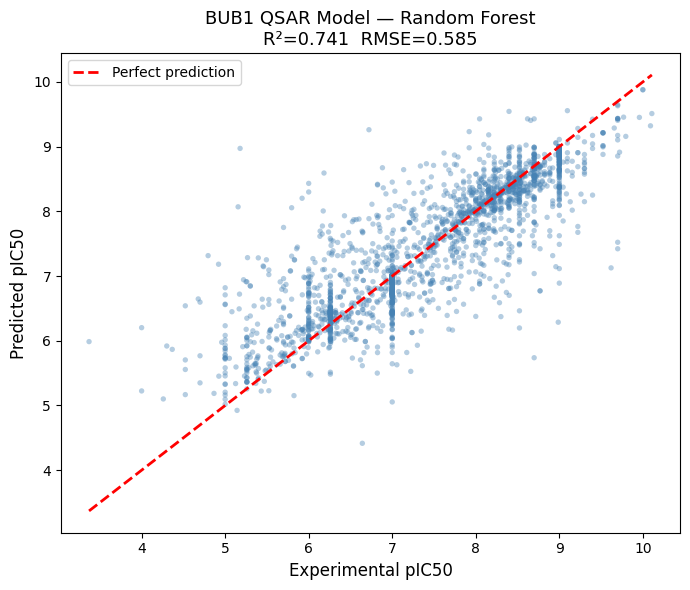

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.4,
           color='steelblue', edgecolors='none', s=15)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel("Experimental pIC50", fontsize=12)
ax.set_ylabel("Predicted pIC50", fontsize=12)
ax.set_title(f"BUB1 QSAR Model — Random Forest\nR²={r2:.3f}  RMSE={rmse:.3f}",
             fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("QSAR_model.png", dpi=150)
plt.show()